"""DON_map_u_nu_to_solution

# Viscous Burgers Equation (Forward mode auto diff)

## Maping sparse data to the solution space

$$ \frac{ds}{dt} + s \frac{ds}{dx} = \nu \frac{d^2s}{dx^2}$$

$$ s(x,0) = u(x), x \in (0,1),$$

$$ s(0,t) = s(1,t), $$

$$ \frac{ds(0,t)}{dx} = \frac{ds(1,t)}{dx},$$
"""

In [1]:
from flax import linen as nn
from typing import Sequence, Tuple
import jax
import jax.numpy as jnp
from torch.utils import data
from functools import partial
import time
import optax
import scipy.io
import os
import argparse
import matplotlib.pyplot as plt
import shutil
import orbax.checkpoint as ocp
import pandas as pd
from jax import jvp
import pickle
from sklearn import metrics
from termcolor import colored
import random
import numpy as np

In [17]:
## All inputs

path = ('/home/droysar1/data_sgoswam4/Dibakar/DeepONet_inverse/Burgers/Burgers_500_nu_20_ic.mat')  # Please use the matlab script to generate data

n_train = 8500
p_data_train = 300
batch_size = 200
n_test = 101
n_sensors = p_data_train
branch_layers = [64, 64, 64]
branch_input_features = 1
trunk_layers = [64, 64, 64]
trunk_input_features = 2
hidden_dim = 100
p_test = 101
result_dir = './'
epochs = 80000
vis_iter = 1000
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

In [3]:
data_ref = scipy.io.loadmat(path)
u_sol_train = jnp.array(data_ref['output_train_u'])

ic_and_nu_train = jnp.array(data_ref['input_train_u0_nu'])

nu_train = ic_and_nu_train[:,-1]
# nu_train = ic_and_nu_train[:,-1]

u_sol_test = jnp.array(data_ref['output_test_u'])

ic_and_nu_test = jnp.array(data_ref['input_test_u0_nu'])
nu_test = ic_and_nu_test[:,-1]
# nu_test = ic_and_nu_test[:,-1]

print("output_train: ", str(u_sol_train.shape))   # (n_train, nt, nx)
print("nu_train: ", str(nu_train.shape))  # (n_train,)
print("output_test: ", str(u_sol_test.shape))  # (n_test, nt, nx)
print("nu_test: ", str(nu_test.shape)) # (n_test,)

2025-10-16 17:15:34.105945: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.68. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


output_train:  (8500, 101, 101)
nu_train:  (8500,)
output_test:  (1500, 101, 101)
nu_test:  (1500,)


(101, 101)


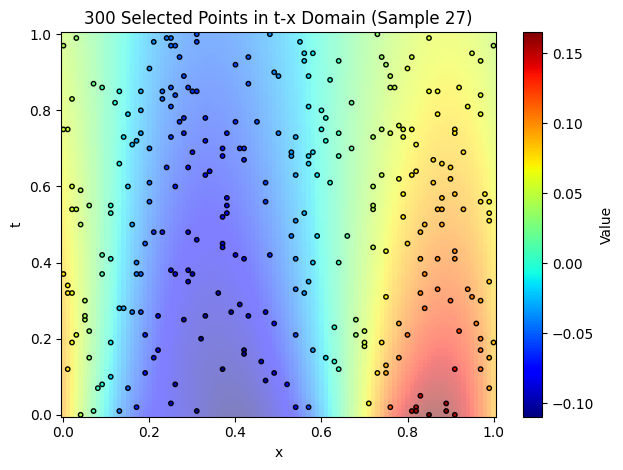

In [5]:
def extract_points(data, num_points=300):
    seed = 0
    key = jax.random.PRNGKey(seed)
    samples, ntt, nxx = data.shape
    flattened_data = data.reshape(samples, ntt * nxx)
#     selected_indices = np.random.choice(height * width, numå_points, replace=False)
    random_indices = jax.random.choice(key, ntt * nxx, shape=(num_points,), replace=False)
#     extracted_data = flattened_data[:, selected_indices]
    t_indices = random_indices // ntt
    x_indices = random_indices % nxx
    t = t_indices / (ntt - 1)
    x = x_indices / (nxx - 1)

    # Create y array with (t, x) coordinates
    location = jnp.stack([t, x], axis=-1)

    # Create a grid representing the original domain
    tt = np.linspace(0, 1, ntt)
    xx = np.linspace(0, 1, nxx)
    XX, TT = jnp.meshgrid(xx, tt, indexing='ij')

    y_test = jnp.stack([TT.flatten(), XX.flatten()], axis=-1)

    # Sample s values from u_data
    extracted_data = data[:,t_indices, x_indices]

    return extracted_data, location, y_test

# Extract 300 points from each sample
data_output, location, y_test = extract_points(u_sol_test, p_data_train)

# Choose a sample to plot (e.g., the first sample)
sample_index = 27

# Create the plot
plt.figure()

# Create a grid representing the original domain
t = np.linspace(0, 1, 101)  # Assuming t goes from 0 to 1
x = np.linspace(0, 1, 101)  # Assuming x goes from 0 to 1
X, T = jnp.meshgrid(x, t, indexing='ij')

print(u_sol_test[sample_index].shape)
# Plot the full domain as a light background
plt.pcolormesh(X, T, u_sol_test[sample_index,:,:].T, cmap='jet', alpha=0.5)

# Get the coordinates of the selected points
# selected_t, selected_x = np.unravel_index(selected_indices, (101, 101))
selected_values = data_output[sample_index]

# Plot the selected points
scatter = plt.scatter(location[:,1], location[:,0], c=selected_values, cmap='jet', s=10, edgecolor='black')

plt.colorbar(scatter, label='Value')
plt.title(f'{p_data_train} Selected Points in t-x Domain (Sample {sample_index})')
plt.xlabel('x')
plt.ylabel('t')

plt.tight_layout()
plt.show()

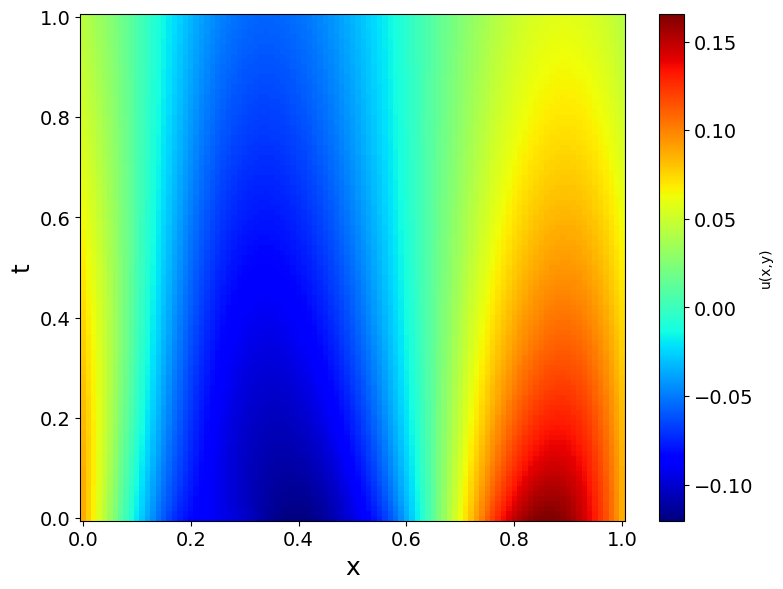

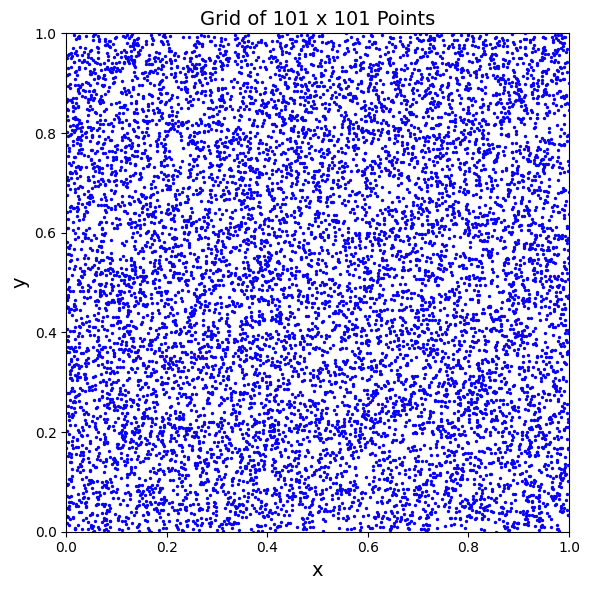

In [6]:
# Plotting with improved aesthetics
plt.figure(figsize=(8, 6))

# Create a grid representing the original domain
t = np.linspace(0, 1, 101)
x = np.linspace(0, 1, 101)
X, T = jnp.meshgrid(x, t, indexing='ij')

# Plot the full domain as a light background
color = plt.pcolormesh(X, T, u_sol_test[sample_index, :, :].T, cmap='jet', alpha=1, shading='auto')

# Get the values of selected points
selected_values = data_output[sample_index]

# Add color bar with label
cbar = plt.colorbar(color, label='u(x,y)')
cbar.ax.tick_params(labelsize=14)

plt.xlabel('x', fontsize=18)
plt.ylabel('t', fontsize=18)

# Ticks with larger font
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Display the plot
plt.tight_layout()
plt.show()

# Set grid size
grid_size = 101

# Generate random x and y coordinates within [0, 1]
x_coords = np.random.rand(grid_size, grid_size)
y_coords = np.random.rand(grid_size, grid_size)

# Plot the grid
plt.figure(figsize=(6, 6))
plt.scatter(x_coords, y_coords, s=2, color='red', edgecolor='blue')

# Set plot title and labels with larger font size for clarity
plt.title('Grid of 101 x 101 Points', fontsize=14)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)

# Set axis limits to [0, 1] to cover the domain
plt.xlim(0, 1)
plt.ylim(0, 1)

# Display the plot
# plt.grid(True)
plt.tight_layout()
plt.show()

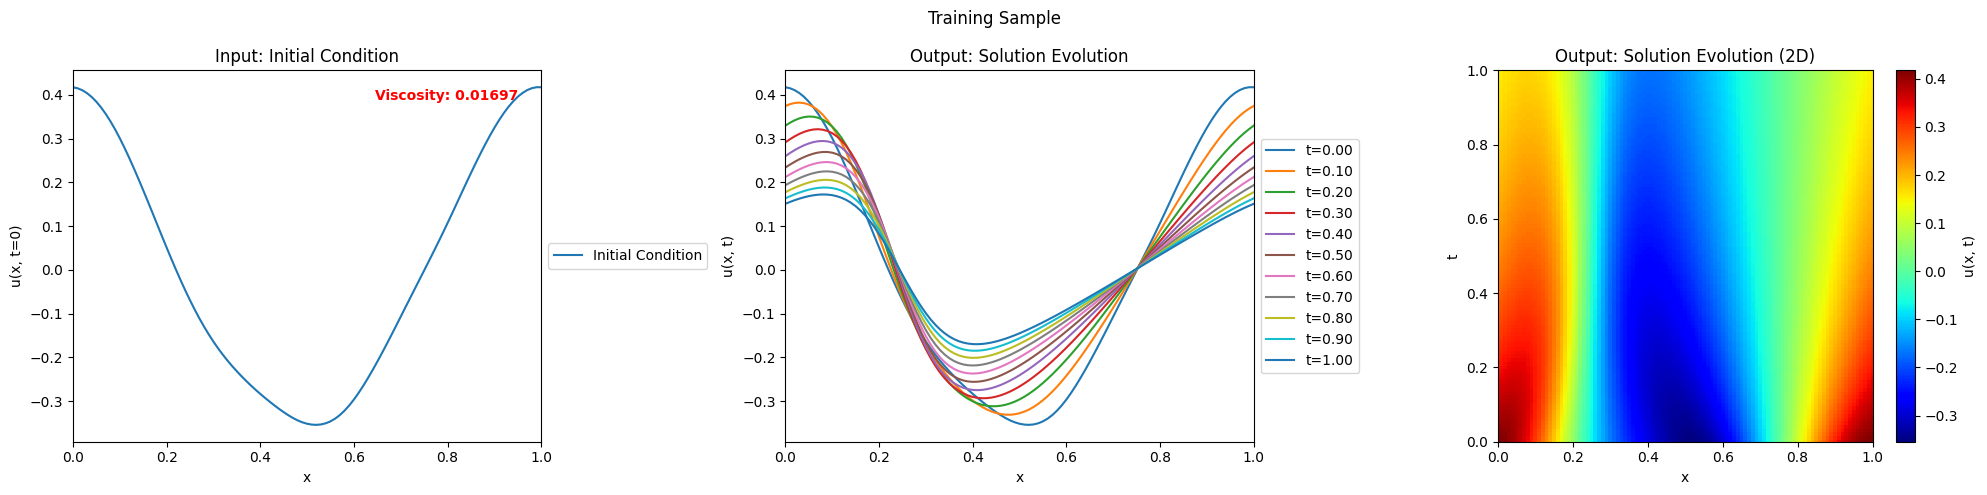

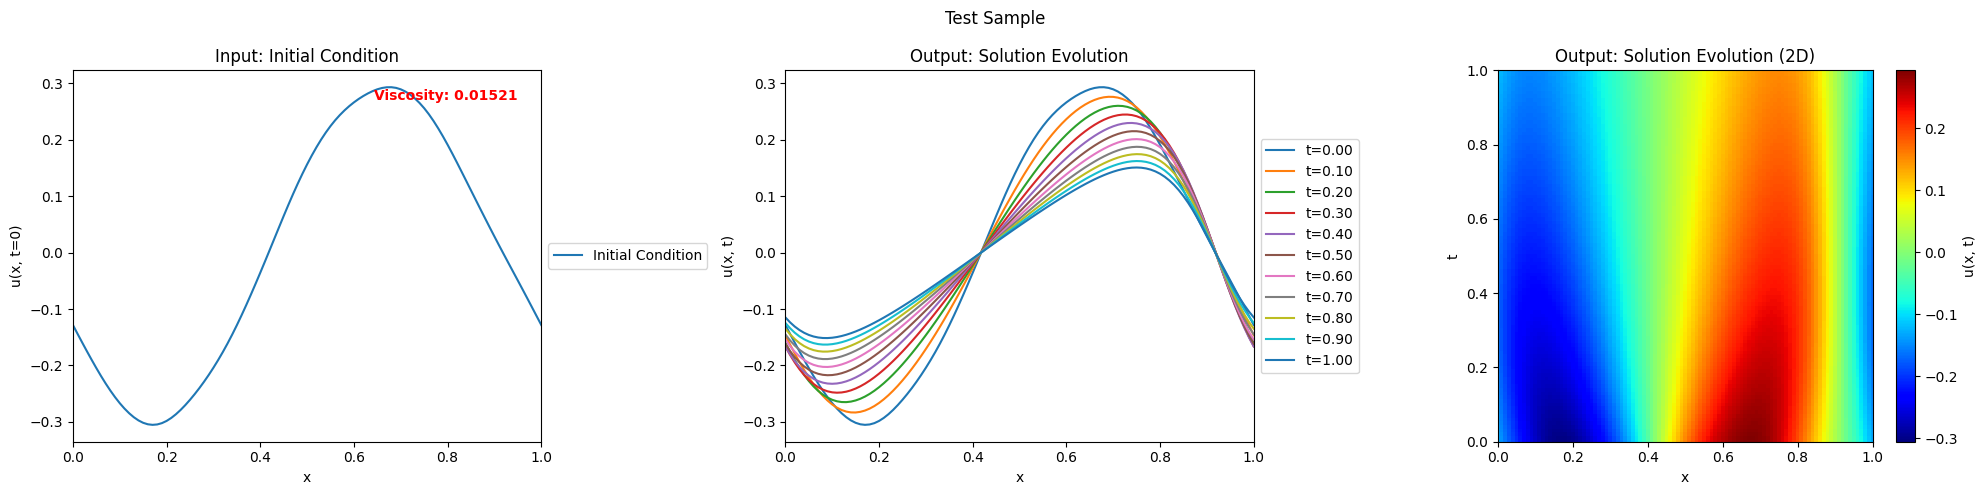

In [7]:
# Function to plot input and output for a single sample
def plot_sample(ic_and_nu, u_sol, sample_index, title):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(title)

    # Create x and t arrays for the physical domain
    x = np.linspace(0, 1, ic_and_nu.shape[1] - 1)
    t = np.linspace(0, 1, u_sol.shape[1])

    XX, TT = jnp.meshgrid(x, t, indexing='ij')

    # Plot input
    ax1.plot(x, ic_and_nu[sample_index, :-1], label='Initial Condition')
    ax1.set_title('Input: Initial Condition')
    ax1.set_xlabel('x')
    ax1.set_ylabel('u(x, t=0)')
    ax1.set_xlim(0, 1)
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Display viscosity as text
    viscosity = ic_and_nu[sample_index, -1]
    ax1.text(0.95, 0.95, f'Viscosity: {viscosity:.5f}',
             verticalalignment='top', horizontalalignment='right',
             transform=ax1.transAxes, color='red', fontweight='bold')

    # Plot output as line plots
    for i in range(0, u_sol.shape[1], 10):  # Plot every 10th time step
        ax2.plot(x, u_sol[sample_index, i, :], label=f't={t[i]:.2f}')
    ax2.set_title('Output: Solution Evolution')
    ax2.set_xlabel('x')
    ax2.set_ylabel('u(x, t)')
    ax2.set_xlim(0, 1)
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Plot output as pcolor (flipped)
    im = ax3.pcolormesh(XX, TT, u_sol[sample_index, :, :].T, cmap='jet', shading='auto')
    ax3.set_title('Output: Solution Evolution (2D)')
    ax3.set_xlabel('x')
    ax3.set_ylabel('t')
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    fig.colorbar(im, ax=ax3, label='u(x, t)')

    plt.tight_layout()
    plt.show()

# Plot a sample from the training set
train_sample_index = 201  # You can change this to view different samples
plot_sample(ic_and_nu_train, u_sol_train, train_sample_index, "Training Sample")

# Plot a sample from the test set
test_sample_index = 4  # You can change this to view different samples
plot_sample(ic_and_nu_test, u_sol_test, test_sample_index, "Test Sample")

In [8]:
# Data Generator
class DataGenerator(data.Dataset):
    def __init__(self, u, y, s, batch_size, gen_key):
        self.u = u # data
        self.y = y
        self.s = s # full solution
        self.N = u.shape[0]
        self.batch_size = batch_size
        self.key = gen_key

    def __getitem__(self, index):
        """Generate one batch of data"""
        self.key, subkey = jax.random.split(self.key)
        inputs, outputs = self.__data_generation(subkey)
        return inputs, outputs

    @partial(jax.jit, static_argnums=(0,))
    def __data_generation(self, key_i):
        """Generates data containing batch_size samples"""
        idx = jax.random.choice(key_i, self.N, (self.batch_size,), replace=False)
        s = self.s[idx, :]
        y = self.y[:, :]
        u = self.u[idx, :]
        # Construct batch
        inputs = (u, y)
        outputs = s
        return inputs, outputs

In [9]:
def generate_random_data_points(nu_train_i, u_sol_train_i, key, num_points=300):

    # Generate random indices for sampling points
    num_t, num_x = u_sol_train_i.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(num_points,), replace=False)

    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_x
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)

    # Create y array with (t, x) coordinates
    y = jnp.stack([t, x], axis=-1)

    # Sample s values from u_data
    u = u_sol_train_i[t_indices, x_indices]

    s = u_sol_train_i

    return u, y, u, nu_train_i

In [11]:
#Create test data
seed = 0
key = jax.random.PRNGKey(seed)
keys = jax.random.split(key, 6)


u_data_train, y_data_train, s_data_train, nu_data_train = (jax.vmap(generate_random_data_points,
                                                     in_axes=(0, 0, None, None))
                                            (nu_train, u_sol_train, key, p_data_train))

print("u_data_train: ", str(u_data_train.shape))  # Expected: (N_train, 300)
print("s_data_train: ", str(s_data_train.shape))  # Expected: (N_train, 101, 101)
print("y_data_train: ", str(y_data_train.shape))  # Expected: (N_train, 300, 2)
print("nu_data_train: ", str(nu_data_train.shape))  # Expected: (N_train,)

# Create data generators
data_dataset = DataGenerator(u_data_train, y_data_train, s_data_train, batch_size, keys[3])

u_data_train:  (8500, 300)
s_data_train:  (8500, 300)
y_data_train:  (8500, 300, 2)
nu_data_train:  (8500,)


In [12]:
# DeepONet class

class DeepONet(nn.Module):
    branch_layers: Sequence[int]
    trunk_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, branch_x, trunk_x):

        init = nn.initializers.glorot_normal()

        if branch_x.ndim == 1:
            branch_x = jnp.expand_dims(branch_x, axis=-1)

#         print("branch_x_in: ", str(branch_x.shape))
        # Branch network [batch_size, 1]
        for i, fs in enumerate(self.branch_layers[:-1]):
            branch_x = nn.Dense(fs, kernel_init=init, name=f"branch_{i}")(branch_x)
            branch_x = nn.activation.tanh(branch_x)
        branch_x = nn.Dense(self.branch_layers[-1], name=f"branch_{i+1}", kernel_init=init)(branch_x)
        #[batch_size, p]
#         print("branch_x_out: ", str(branch_x.shape))

        # Trunk network
        # [x_num, 2]
        # Ensure trunk_x has at least 2 dimensions
        if trunk_x.ndim == 1:
            trunk_x = jnp.expand_dims(trunk_x, axis=0)

#         print("trunk_x_in: ", str(trunk_x.shape))

        for i, fs in enumerate(self.trunk_layers):
            trunk_x = nn.Dense(fs, kernel_init=init, name=f"trunk_{i}")(trunk_x)
            trunk_x = nn.activation.tanh(trunk_x)

#         print("trunk_x_out: ", str(trunk_x.shape))

         # [x_num, p]

        # Compute the final output
        # Input shapes:
        # branch: [batch_size, p]
        # trunk: [x_num, p]
        # output: [batch_size, x_num]
        result = jnp.einsum('ij,kj->ik', branch_x, trunk_x)

        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        result += bias

        return result

In [13]:
"""# Helper functions"""

@partial(jax.jit)
def mse(y_true, y_pred):
    return jnp.mean(jnp.square(y_true - y_pred))

@partial(jax.jit)
def mse_single(y_pred):
    return jnp.mean(jnp.square(y_pred))

@partial(jax.jit, static_argnums=(0,))
def apply_net(model_fn, params, branch_input, *trunk_in):
    # Define forward pass for normal DeepOnet that takes series of trunk inputs and stacks them
    if len(trunk_in) == 1:
        trunk_input = trunk_in[0]
    else:
        trunk_input = jnp.stack(trunk_in, axis=-1)
    out = model_fn(params, branch_input, trunk_input)

    # Reshape to vector for single output for easier gradient computation
    # TODO: Adapt / Check squeeze
    if out.shape[1]==1:
        out = jnp.squeeze(out, axis=1)
    return out


@partial(jax.jit, static_argnums=(0, 1, 2))
def step(optimizer, loss_fn, model_fn, opt_state, params_step, data_batch):
    loss, gradient = jax.value_and_grad(loss_fn, argnums=1)(model_fn, params_step, data_batch)
    updates, opt_state = optimizer.update(gradient, opt_state)
    params_step = optax.apply_updates(params_step, updates)

    return loss, params_step, opt_state


In [14]:
"""# Loss functions"""

def loss_fn(model_fn, params, data_batch):

    inputs, outputs = data_batch
    u_data, y = inputs

#     rand_num = random.randint(0, n_train)
    t = y[1, :, 0] # pick y for one sample (y is same for all samples)
    x = y[1, :, 1]
#     print(t.shape)
#     print(x.shape)
    s_pred = apply_net(model_fn, params, u_data, t, x)

    loss = mse(outputs, s_pred)
    return loss

In [18]:
"""# Initialize the model"""

# Initialize model and params
# make sure trunk_layers and branch_layers are lists
trunk_layers = [trunk_layers] if isinstance(trunk_layers, int) else trunk_layers

branch_layers = [branch_layers] if isinstance(branch_layers, int) else branch_layers

# add output features to trunk and branch layers
trunk_layers = trunk_layers + [hidden_dim]
branch_layers = branch_layers + [hidden_dim]

# Convert list to tuples
trunk_layers = tuple(trunk_layers)
branch_layers = tuple(branch_layers)

num_outputs = 1
model = DeepONet(branch_layers, trunk_layers, num_outputs)

params = model.init(key, jnp.ones(shape=(1, n_sensors * branch_input_features)),
                    jnp.ones(shape=(1, trunk_input_features)))

# Print model from parameters
print('--- model_summary ---')
# count total params
total_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f'total params: {total_params}')
print('--- model_summary ---')

# model function
model_fn = jax.jit(model.apply)


--- model_summary ---
total params: 49097
--- model_summary ---


In [19]:
"""# Test error function"""

def loss_test_l2_error(model_fn, params, data_output, u_sol_test, return_data=False):

    def ff_net(t_test, x_test):
        s_pred = apply_net(model_fn, params, data_output, t, x)
        return s_pred

     # Generate random indices for sampling points
    _, num_t, num_x = u_sol_test.shape
    total_points = num_t * num_x
    random_indices = jax.random.choice(key, total_points, shape=(300,), replace=False)

    # Calculate t and x coordinates for the sampled points
    t_indices = random_indices // num_x
    x_indices = random_indices % num_x
    t = t_indices / (num_t - 1)
    x = x_indices / (num_x - 1)

    # Create y array with (t, x) coordinates
    y = jnp.stack([t, x], axis=-1)

    # Sample s values from u_data
    u = u_sol_test[:, t_indices, x_indices]

    s_pred = ff_net(t, x)

    loss_test = mse(u, s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(jax.vmap(l2_norm_error)(u, s_pred))

    if return_data:
        return loss_test, l2_error, s_pred
    else:
        return loss_test, l2_error

In [20]:
"""# Define optimiser"""

# Define optimizer with optax (ADAM)
# optimizer

lr_scheduler = optax.exponential_decay(lr, transition_steps, decay_rate)

# lr_scheduler = optax.constant_schedule(1e-3)

optimizer = optax.adam(learning_rate=lr_scheduler)
opt_state = optimizer.init(params)

# Data
data_data = iter(data_dataset)

# create dir for saving results
result_dir = os.path.join(os.getcwd(), os.path.join(result_dir, f"results_burgers_{seed}"))
log_file = os.path.join(result_dir, 'log.csv')
# Create directory
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
if os.path.exists(os.path.join(result_dir, 'vis')):
    shutil.rmtree(os.path.join(result_dir, 'vis'))
if os.path.exists(log_file):
    os.remove(log_file)


with open(log_file, 'a') as f:
    f.write('epoch,loss,l2err_test,loss_test,runtime\n')

In [21]:
"""# model save function"""

def save_model_params(params, result_dir, filename='model_params.pkl'):
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)

    save_path = os.path.join(result_dir, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

def load_model_params(result_dir, filename='model_params.pkl'):
    load_path = os.path.join(result_dir, filename)
    with open(load_path, 'rb') as f:
        params = pickle.load(f)
    return params

# Usage:
save = True
# Saving
if save:
    save_model_params(params, result_dir)

In [22]:
"""# Training loop"""

# Iterations
epochs = epochs  # Assuming 'epochs' is defined elsewhere
log_iter = 1000
best_test_mse = float('inf')  # Initialize with infinity
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_best.pkl')
print("Saved initial model at iteration 0")
# Training loop
for it in range(epochs):
    if it == 1:
        # start timer and exclude first iteration (compile time)
        start = time.time()
    # Fetch data
    data_batch = next(data_data)

    # Do Step
    loss, params, opt_state = step(optimizer, loss_fn, model_fn, opt_state,
                                   params, data_batch)
    if it % log_iter == 0:
        # Compute losses
        loss = loss_fn(model_fn, params, data_batch)

        # Calculate loss and l2 error for test samples
        loss_test, l2_error = loss_test_l2_error(model_fn, params, data_output, u_sol_test, return_data=False)

        if loss_test < best_test_mse:
            best_test_mse = loss_test
            # Save the model as it's the best so far
            save_model_params(params, result_dir, filename='model_params_best.pkl')
            print(f"New best model saved at iteration {it} with test MSE: {loss_test:.2e}")

        # get runtime
        if it == 0:
            runtime = 0
        else:
            runtime = time.time() - start

        # Print losses
        print(f"Iteration {it+1}/{epochs}")
        print(f"Trian_loss: {loss:.2e},"
              f"l2_err_test: {l2_error:.2e}, test_loss: {loss_test:.2e} , runtime: {runtime:.2e}")

        # Save results
        with open(log_file, 'a') as f:
            f.write(f'{it+1}, {loss},'
                    f'{l2_error}, {loss_test}, {runtime}\n')

# Save results
runtime = time.time() - start
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_last.pkl')
print("Saved model at end of training")
with open(log_file, 'a') as f:
    f.write(f'{it + 1}, {loss},'
            f'{l2_error}, {loss_test}, {runtime}\n')


Saved initial model at iteration 0
New best model saved at iteration 0 with test MSE: 0.0682295
Iteration 1/80000
Trian_loss: 6.28e-02,l2_err_test: 2.15e+00, test_loss: 6.82e-02 , runtime: 000.00
New best model saved at iteration 1000 with test MSE: 0.0010956
Iteration 1001/80000
Trian_loss: 1.15e-03,l2_err_test: 2.85e-01, test_loss: 1.10e-03 , runtime: 000.82
New best model saved at iteration 2000 with test MSE: 0.0005612
Iteration 2001/80000
Trian_loss: 5.17e-04,l2_err_test: 2.08e-01, test_loss: 5.61e-04 , runtime: 001.63
New best model saved at iteration 3000 with test MSE: 0.0003341
Iteration 3001/80000
Trian_loss: 3.43e-04,l2_err_test: 1.59e-01, test_loss: 3.34e-04 , runtime: 002.43
New best model saved at iteration 4000 with test MSE: 0.0002376
Iteration 4001/80000
Trian_loss: 2.61e-04,l2_err_test: 1.37e-01, test_loss: 2.38e-04 , runtime: 003.23
New best model saved at iteration 5000 with test MSE: 0.0001651
Iteration 5001/80000
Trian_loss: 1.50e-04,l2_err_test: 1.14e-01, test_lo

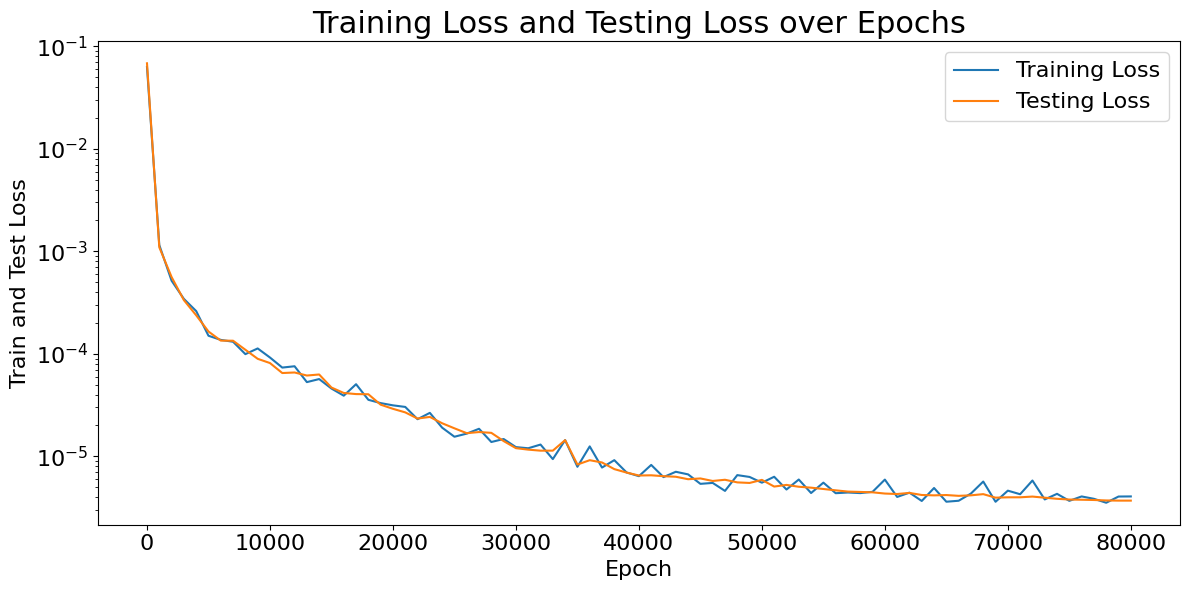

Plots saved to /scratch4/sgoswam4/Dibakar/INV_DON/Burgers_dist/./results_burgers_0/train_and_test_loss_plots.png


In [23]:
"""# Loss plots"""

# Set the result directory
# result_dir = "/kaggle/input/csv-log"

# Read the CSV file
csv_file = os.path.join(result_dir, "log.csv")  # Assuming the file is named "log.csv"
df = pd.read_csv(csv_file)

# Create the figure with two subplots side by side

# Set color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Right plot: epoch vs loss and l2err_val
plt.figure(figsize=(12, 6))
plt.plot(df['epoch'], df['loss'], label='Training Loss', color=colors[0], linestyle='-')
plt.plot(df['epoch'], df['loss_test'], label='Testing Loss', color=colors[1], linestyle='-')
plt.yscale("log")
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Train and Test Loss', fontsize=16)
plt.title('Training Loss and Testing Loss over Epochs', fontsize=22)
plt.legend(loc='best', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Adjust layout and save the figure
plt.tight_layout()
output_file = os.path.join(result_dir, "train_and_test_loss_plots.png")
plt.savefig(output_file, dpi=100)
plt.show()
plt.close()

print(f"Plots saved to {output_file}")

In [24]:
"""# Test visualization"""

def loss_test_l2_error_one_sample(model_fn, params, data_output, u_sol_test, idx, return_data=False):

#     data_sol_f1_test = jnp.moveaxis(data_sol_f1_test, -1, 1) # shape [n_f, nx, nt]

    t_test = jnp.linspace(0, 1, u_sol_test.shape[1])
    x_test = jnp.linspace(0, 1, u_sol_test.shape[2])

    xx_test, tt_test = jnp.meshgrid(x_test, t_test, indexing='ij')

    y = jnp.stack([tt_test.flatten(), xx_test.flatten()], axis=-1) #(100*100, 2)

    t = y[:,0]
    x = y[:,1]

    data_output_i = data_output[idx, :]
    data_output_i = data_output_i[jnp.newaxis,:]
#     print(data_output_i.shape)
    def ff_net(t_test, x_test):
        s_pred = apply_net(model_fn, params, data_output_i, t, x)
        return s_pred

    s_pred = ff_net(t, x)

    s_pred = s_pred.reshape(u_sol_test.shape[1], u_sol_test.shape[2])

#     print("s_pred_loss_test_reshaped: ", str(s_pred.shape))

    loss_test = mse(u_sol_test[idx, :, :], s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

#     l2_error = jnp.mean(jax.vmap(l2_norm_error)(u_sol_test[idx,:,:], s_pred))
    l2_error = jnp.mean(l2_norm_error(u_sol_test[idx,:,:], s_pred))


    if return_data:
        return loss_test, l2_error, s_pred, u_sol_test[idx,:,:]
    else:
        return loss_test, l2_error

def visualize_show(model_fn, params, result_dir, epoch, data_output, u_sol_test, nu_test, idx, test=False):
    # Generate data, and obtain error
#     error_s, error_nu, s_pred, nu, nu_test
    loss_test, l2_error, s_pred, s_test = loss_test_l2_error_one_sample(model_fn, params, data_output, u_sol_test, idx, return_data=True)

    # Modify x and t to match the shapes of u and s_pred
    x = jnp.linspace(0, 1, s_pred.shape[1])
    t = jnp.linspace(0, 1, s_pred.shape[0])

    x_test, t_test = jnp.meshgrid(x, t, indexing='ij')


    # Calculate R² score
    r2_value = metrics.r2_score(s_test.T.flatten(), s_pred.flatten())
    r2_value = float('%.4f' % r2_value)

    # Plot
    fig = plt.figure(figsize=(12, 4))

    # Adjusting layout for more vertical space
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.7, wspace=0.4, hspace=0.1)


#     print(output_data[idx,:,:].shape)
    # Plot Exact u over time using pcolor
    ax = fig.add_subplot(1, 3, 1)
    plt.pcolor(x_test, t_test, s_test.T, cmap='jet', shading='auto')
    plt.colorbar()
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_title('True field', fontsize=14)
    plt.tight_layout()


    # Plot Predicted u over time using pcolor
    ax = fig.add_subplot(1, 3, 2)
    plt.pcolor(x_test, t_test, s_pred, cmap='jet', shading='auto')
    plt.colorbar()
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_title('Predicted field', fontsize=14)
    plt.tight_layout()

    # Plot Absolute error using pcolor

    u_diff = s_test.T - s_pred

    ax = fig.add_subplot(1, 3, 3)
    plt.pcolor(x_test, t_test, jnp.abs(u_diff), cmap='jet', shading='auto')
    plt.colorbar()
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_title('Absolute error', fontsize=14)
    plt.tight_layout()


    if test:
        plt.suptitle(f'Test L2: {l2_error:.3e}, R2: {r2_value}, nu: {nu_test[idx]}', y=1.05)
    else:
        plt.suptitle(f'Train L2: {l2_error:.3e}, R2: {r2_value}', y=1.05)

    # Show or save the plot
    if save:
        plt.savefig(os.path.join(result_dir, f'Test_Sample_{idx+1}.pdf'))
    plt.show()
    plt.close()
    print(colored('#' * 230, 'green'))
    return r2_value

Loaded best model parameters
Visualizing test sample at index 0


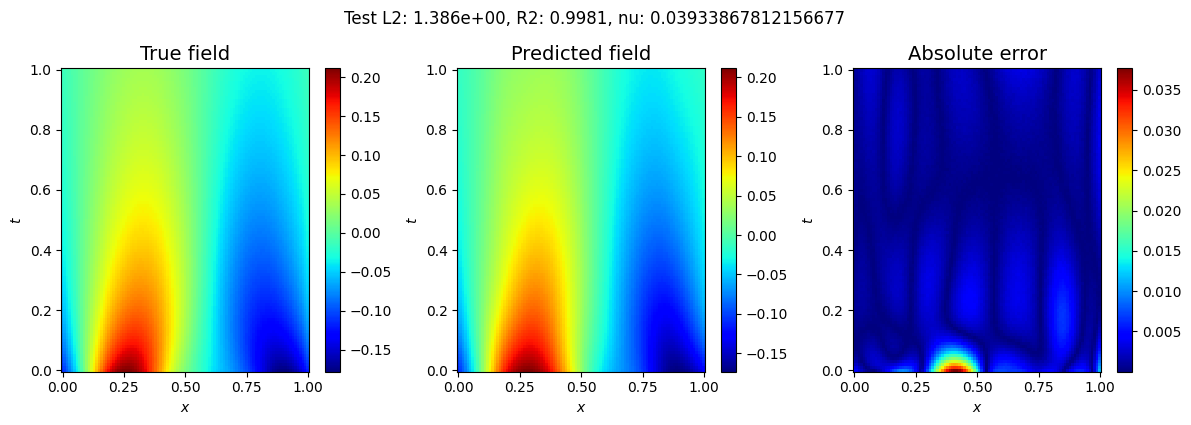

######################################################################################################################################################################################################################################
Visualizing test sample at index 100


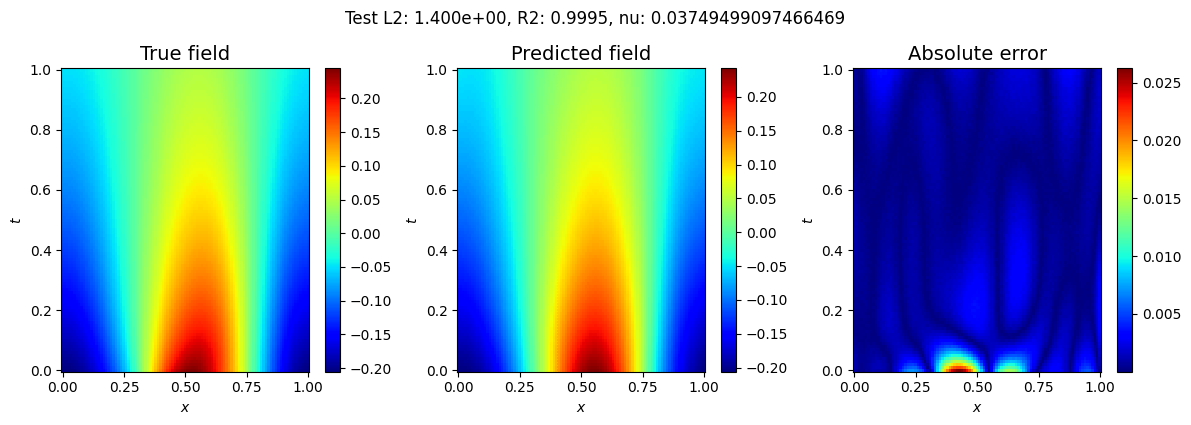

######################################################################################################################################################################################################################################
Visualizing test sample at index 200


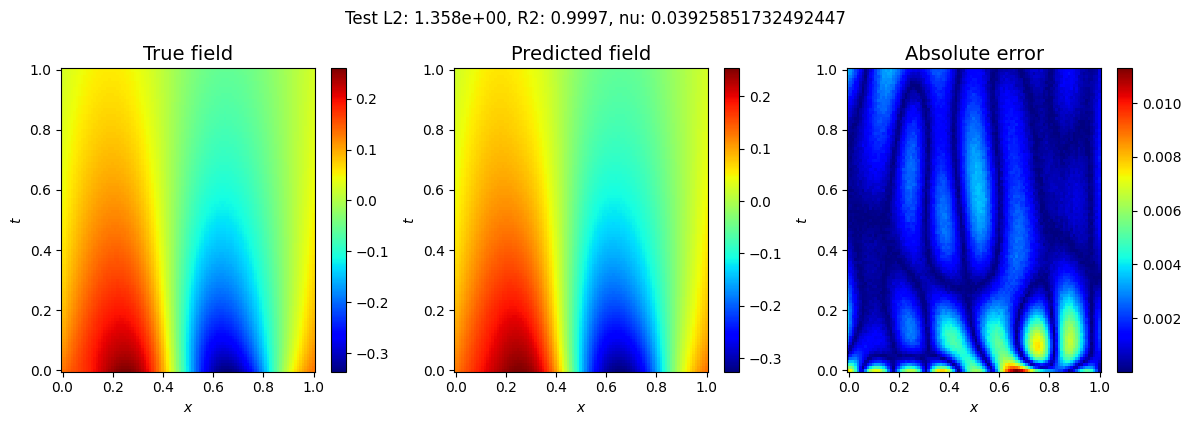

######################################################################################################################################################################################################################################
Visualizing test sample at index 300


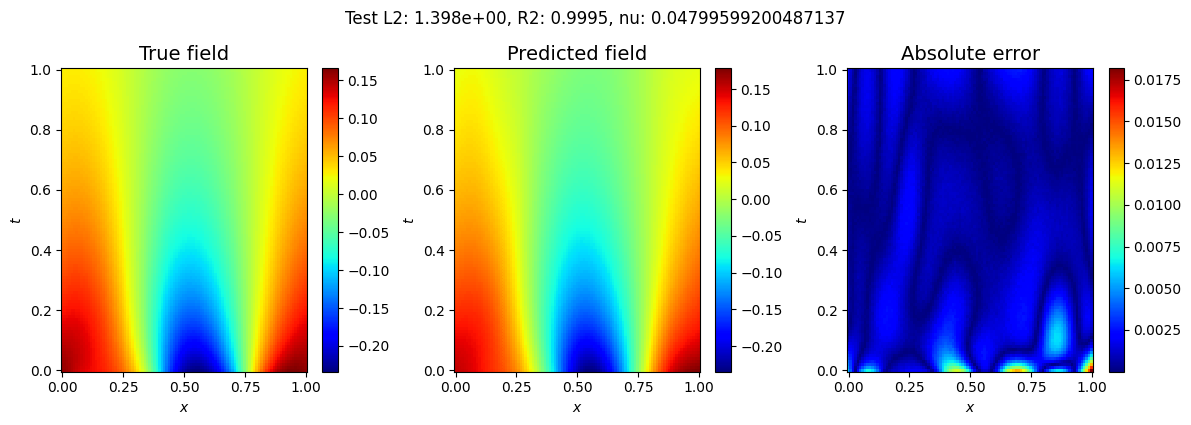

######################################################################################################################################################################################################################################
Visualizing test sample at index 400


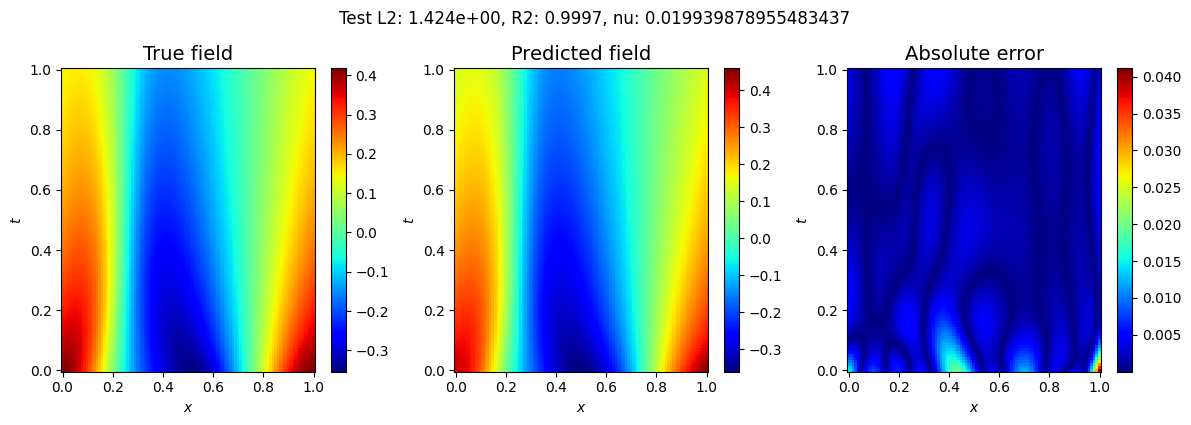

######################################################################################################################################################################################################################################
Visualizing test sample at index 500


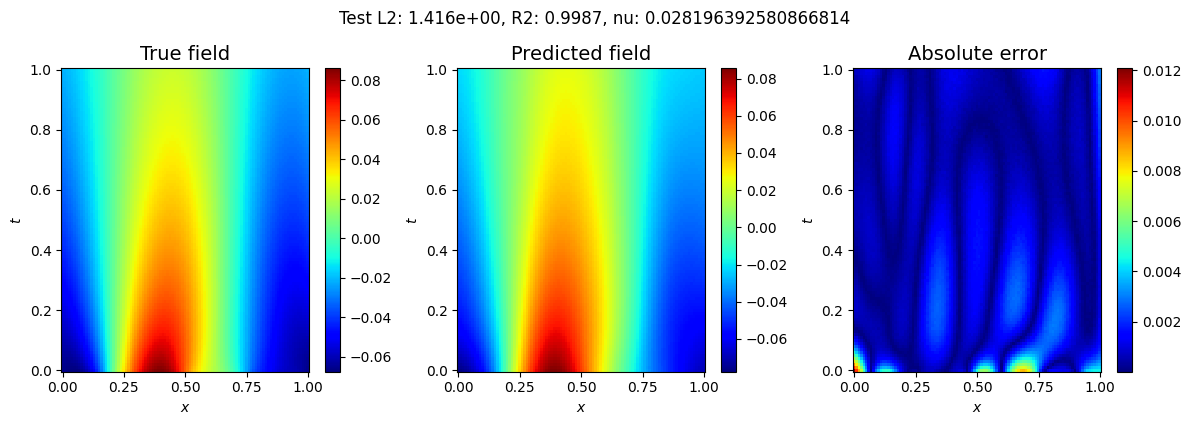

######################################################################################################################################################################################################################################
Visualizing test sample at index 600


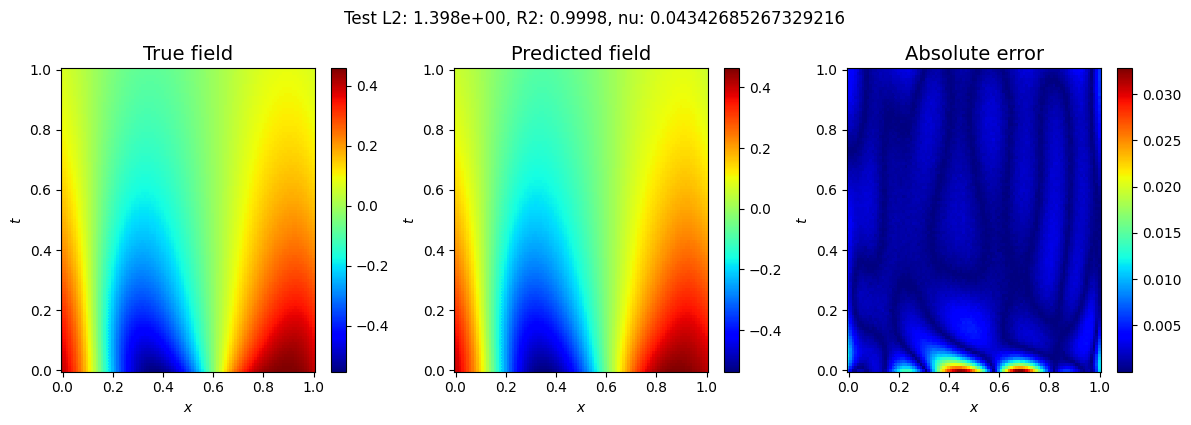

######################################################################################################################################################################################################################################
Visualizing test sample at index 700


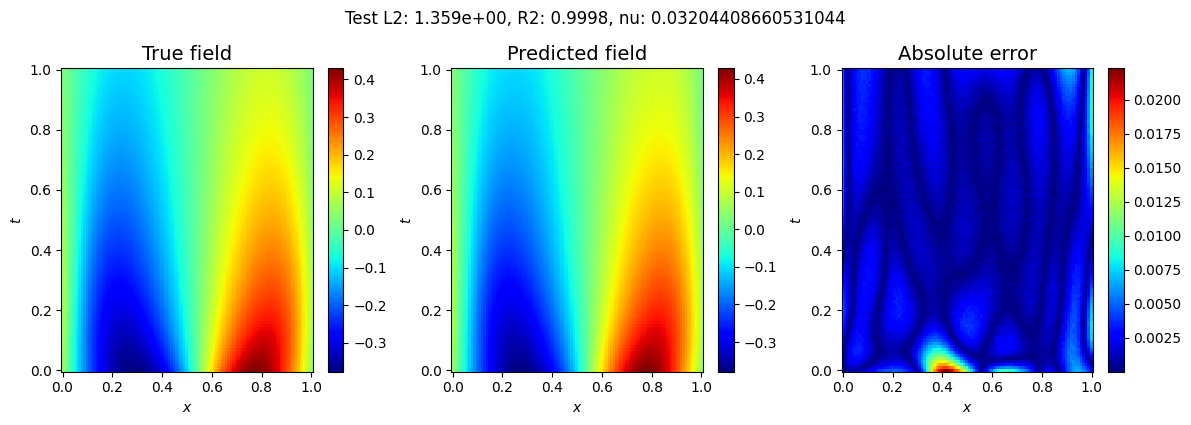

######################################################################################################################################################################################################################################
Visualizing test sample at index 800


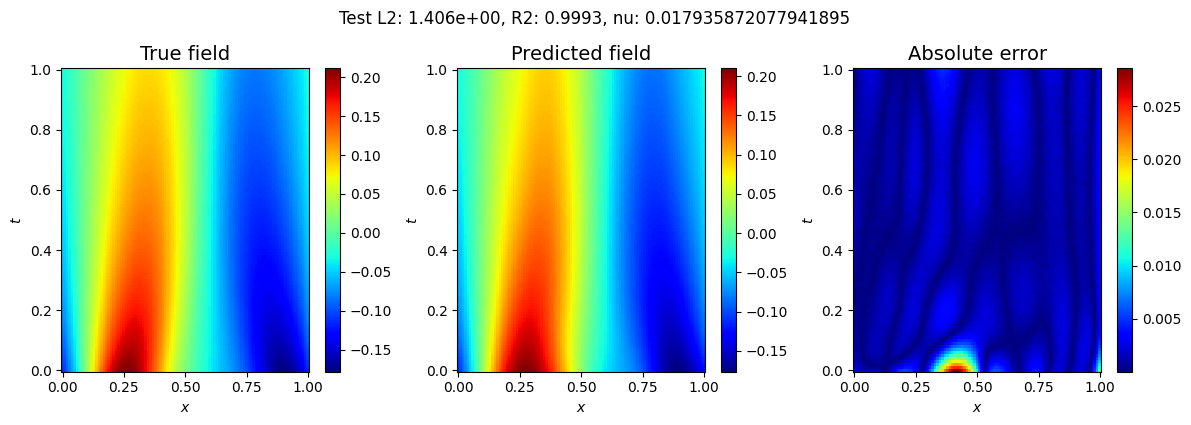

######################################################################################################################################################################################################################################
Visualizing test sample at index 900


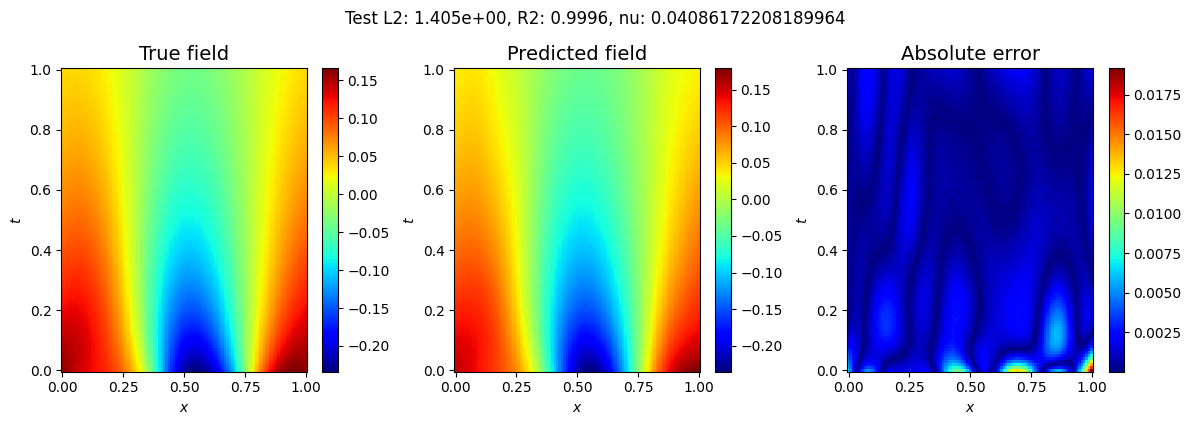

######################################################################################################################################################################################################################################
Visualizing test sample at index 1000


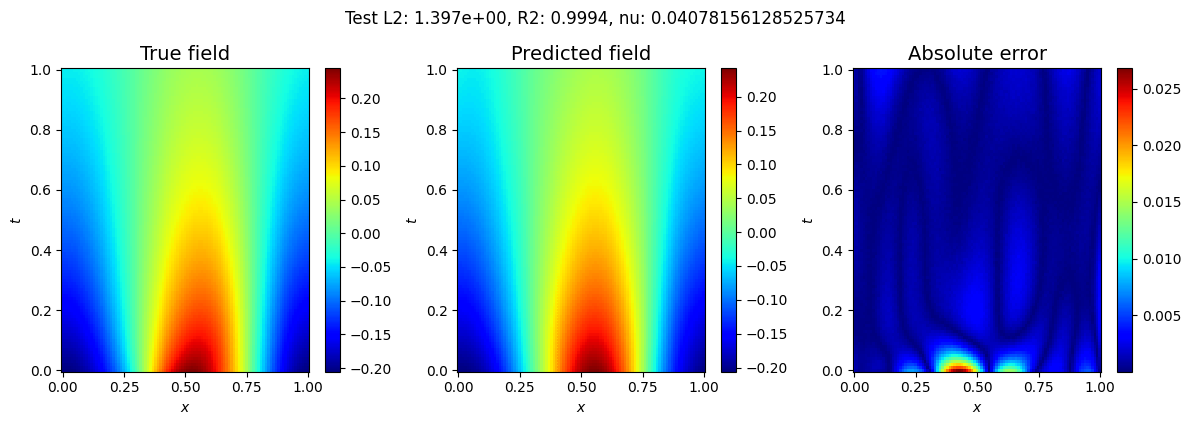

######################################################################################################################################################################################################################################
Visualizing test sample at index 1100


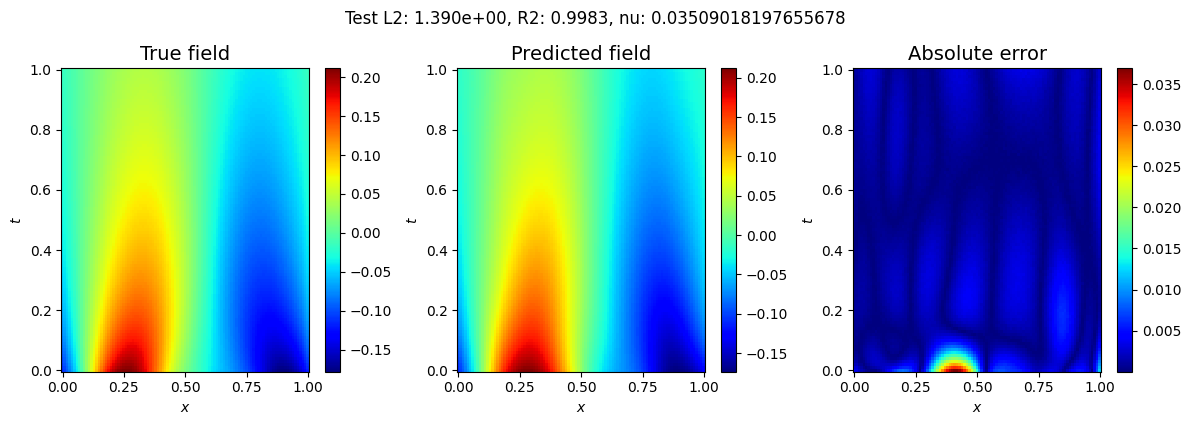

######################################################################################################################################################################################################################################
Visualizing test sample at index 1200


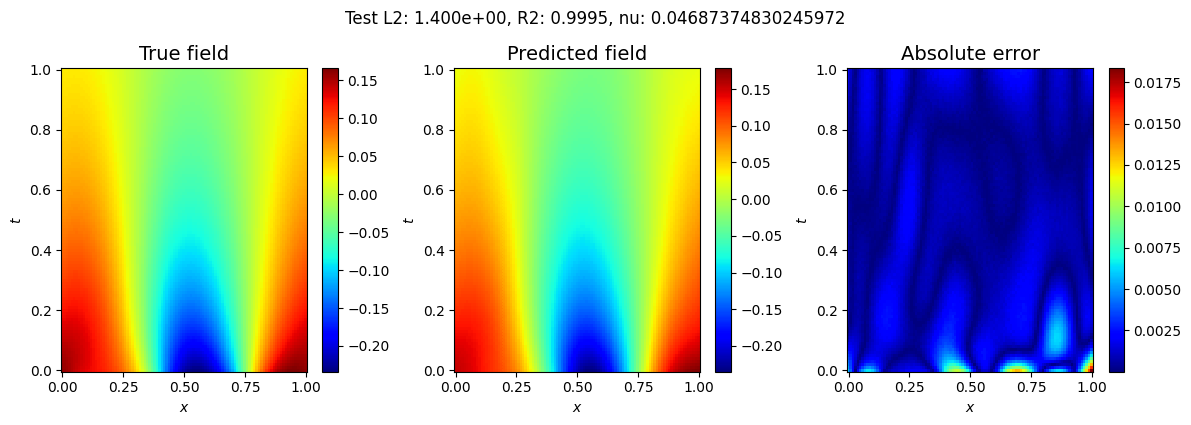

######################################################################################################################################################################################################################################
Visualizing test sample at index 1300


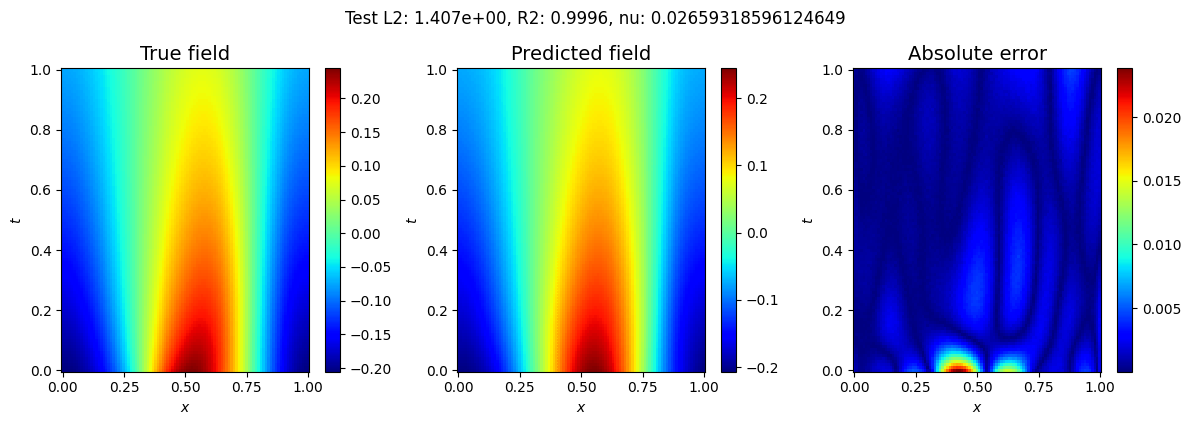

######################################################################################################################################################################################################################################
Visualizing test sample at index 1400


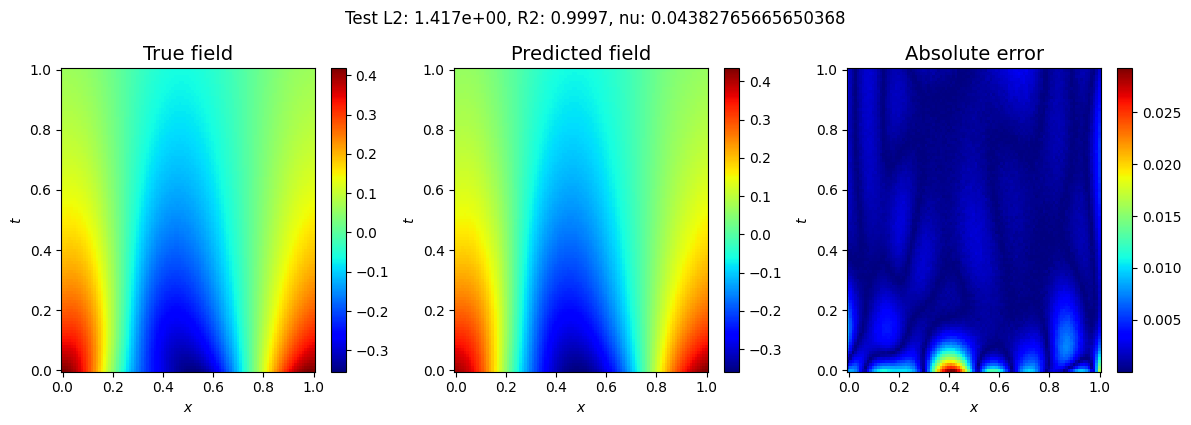

######################################################################################################################################################################################################################################
Mean MSE over test samples: 3.676e-06


In [25]:
# Initialize an empty list to store MSE values
mse_values = []

# Load the best model parameters
best_params = load_model_params(result_dir, filename='model_params_best.pkl')
print("Loaded best model parameters")


# Loop over every 20th index to visualize and calculate R²
for i in range(u_sol_test.shape[0]):
    if i % 100 == 0:
        idx = i
        print(f"Visualizing test sample at index {idx}")

        # Visualize and calculate R² score for every 20th index
        visualize_show(model_fn, best_params, result_dir, epochs, data_output, u_sol_test, nu_test, idx, True)

# Calculate loss and l2 error for test samples
loss_test, l2_error = loss_test_l2_error(model_fn, params, data_output, u_sol_test, return_data=False)

# Calculate and print the mean MSE over all test samples
# mean_mse = jnp.mean(jnp.array(mse_values))
print(f"Mean MSE over test samples: {loss_test:.3e}")

In [26]:
"""# Save inputs"""

def save_inputs_to_txt(file_path):
    variables_to_save = [
        'path', 'n_train', 'p_data_train',
        'batch_size', 'n_test', 'n_sensors', 'branch_layers', 'branch_input_features',
        'trunk_layers', 'trunk_input_features', 'hidden_dim', 'p_test', 'result_dir',
        'epochs', 'vis_iter', 'lr', 'transition_steps', 'decay_rate'
    ]

    with open(file_path, 'w') as f:
        for var_name in variables_to_save:
            value = globals()[var_name]
            f.write(f"{var_name} = {value}\n")

# Save inputs
inputs_file_path = os.path.join(result_dir, "inputs.txt")
save_inputs_to_txt(inputs_file_path)
print(f"Inputs saved to: {inputs_file_path}")

Inputs saved to: /scratch4/sgoswam4/Dibakar/INV_DON/Burgers_dist/./results_burgers_0/inputs.txt
